# Multiscale impact-residual workbench

This notebook treats excess impact as the primary candidate alpha factor. The
decision clock, impact-measurement window and future-return horizon are separate.
All impact curves and residual thresholds are fitted using the training portion of
each chronological fold and then frozen for its following test period.

The impact curve itself is calibrated only on globally aligned, non-overlapping
blocks at its measurement scale. That frozen curve is then applied to rolling
measurements at every decision-bar close.

This is a diagnostic notebook, not a profitability model. Reported returns are
gross bar-close-to-future-bar returns with overlapping signals.

## Manual controls

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')

RESULT_ROOT = Path('/Users/petermillington/research/market-impact-research/alpha-search/experiments/sandbox_impact_residual_multiscale_v1/results')
DECISION_EVENTS = 200       # 200, 500 or 1_000
HORIZON_MINUTES = 10    # 10 or 15
SIDE = 'sell'                        # 'sell' or 'buy'
FOLD = 0                             # impact-curve calibration fold to inspect
FIT_MEASUREMENT_EVENTS = 4_000       # detailed fit-family comparison

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})
COLOURS = {200: '#64748b', 500: '#0284c7', 1000: '#7c3aed', 4000: '#c2413b'}

## Definitions

For a trailing measurement window containing `M` reconstructed events, define
the normalised absolute imbalance `x` and signed impact `I` at that scale. A
separate buy or sell curve is fitted in each training fold:

$$
\widehat I_{s,M}(x)
=
a_{s,M}+b_{s,M}\log\left(1+\frac{x}{c_M}\right).
$$

The primary factor is the excess-impact residual:

$$
\varepsilon_t^{(M)}
=
I_t^{(M)}-\widehat I_{s,M}\left(x_t^{(M)}\right).
$$

The window ends at the decision-bar close. Its price response and net signed flow
are recomputed over the whole window; smaller-bar residuals are not added together.
The volume and volatility benchmarks end before the measurement window begins.

For calibration, only every `M / decision_events` endpoint is retained. Thus the
blocks used to fit the curve partition the event history without sharing events.
For signal construction, the fitted curve is evaluated at every decision-bar close.

Future returns are aligned with the net flow side of the measurement window:

$$
R_{t,h}^{\mathrm{aligned}}
=
\operatorname{sign}\left(Q_t^{(M)}\right)
10{,}000\log\left(\frac{P_{t+h}}{P_t}\right).
$$

A negative high-minus-low residual spread means that high excess impact is followed
by greater reversal, or weaker continuation, than low excess impact. A contrarian
trade following a high residual earns the negative of the aligned future return.

## Load the frozen run

In [2]:
manifest = json.loads((RESULT_ROOT / 'run_manifest.json').read_text())
fits = pl.read_csv(RESULT_ROOT / 'fold_impact_fits.csv')
curve_bins = pl.read_csv(RESULT_ROOT / 'fold_impact_curve_bins.csv')
cuts = pl.read_csv(RESULT_ROOT / 'fold_residual_cuts.csv')
quintiles = pl.read_csv(RESULT_ROOT / 'fold_quintile_summary.csv')
contrasts = pl.read_csv(RESULT_ROOT / 'fold_extreme_contrast.csv')
correlations = pl.read_csv(RESULT_ROOT / 'fold_scale_correlation.csv')
aggregate = pl.read_csv(RESULT_ROOT / 'aggregate_extreme_contrast.csv')

diagnostic_root = RESULT_ROOT / 'fit_diagnostics'
diagnostic_bins = pl.concat([
    pl.read_csv(path) for path in sorted(diagnostic_root.glob('*/fit_diagnostic_bins.csv'))
])
diagnostic_metrics = pl.concat([
    pl.read_csv(path) for path in sorted(diagnostic_root.glob('*/fit_diagnostic_metrics.csv'))
])
diagnostic_parameters = pl.concat([
    pl.read_csv(path) for path in sorted(diagnostic_root.glob('*/fit_diagnostic_parameters.csv'))
])
diagnostic_tail_bins = pl.concat([
    pl.read_csv(path) for path in sorted(diagnostic_root.glob('*/fit_diagnostic_tail_bins.csv'))
])
diagnostic_trim_sensitivity = pl.concat([
    pl.read_csv(path) for path in sorted(diagnostic_root.glob('*/fit_diagnostic_trim_sensitivity.csv'))
])

available_windows = (
    fits.filter(pl.col('decision_events') == DECISION_EVENTS)
    ['measurement_events'].unique().sort().to_list()
)
assert HORIZON_MINUTES in manifest['clock_horizons_minutes']
assert SIDE in {'sell', 'buy'}
assert FOLD in fits['fold'].unique().to_list()
assert FIT_MEASUREMENT_EVENTS in available_windows

display({
    'data_fingerprint': manifest['data_fingerprint'],
    'decision_events': DECISION_EVENTS,
    'measurement_windows': available_windows,
    'horizon_minutes': HORIZON_MINUTES,
    'side': SIDE,
    'fit_comparison_measurement_events': FIT_MEASUREMENT_EVENTS,
    'impact_curve_calibration': manifest['impact_curve_calibration'],
    'impact_curve_application': manifest['impact_curve_application'],
    'walk_forward_folds': len(manifest['folds']),
    'cache_fingerprint_verified': manifest['cache_fingerprint_verified'],
})
display(pl.DataFrame(manifest['folds']))

{'data_fingerprint': 'cf5c42aeef099ae3b15b777bf64cdb0ba42a599ce0feb67200c3deee748dd832',
 'decision_events': 200,
 'measurement_windows': [200, 1000, 4000],
 'horizon_minutes': 10,
 'side': 'sell',
 'fit_comparison_measurement_events': 4000,
 'impact_curve_calibration': 'non_overlapping_measurement_blocks',
 'impact_curve_application': 'rolling_at_every_decision_bar_close',
 'walk_forward_folds': 5,
 'cache_fingerprint_verified': False}

fold,train_start,train_end,test_start,test_end,embargo_days
i64,str,str,str,str,i64
0,"""2019-09-01""","""2020-09-01""","""2020-09-01""","""2020-12-01""",1
1,"""2019-12-01""","""2020-12-01""","""2020-12-01""","""2021-03-01""",1
2,"""2020-03-01""","""2021-03-01""","""2021-03-01""","""2021-06-01""",1
3,"""2020-06-01""","""2021-06-01""","""2021-06-01""","""2021-09-01""",1
4,"""2020-09-01""","""2021-09-01""","""2021-09-01""","""2021-12-01""",1


## How long are the measurement windows?

In [3]:
duration_table = (
    fits.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('side') == SIDE)
    )
    .group_by('measurement_events')
    .agg(
        pl.col('training_median_duration_minutes').mean().alias('mean_fold_median_minutes'),
        pl.col('training_median_duration_minutes').min().alias('minimum_fold_median_minutes'),
        pl.col('training_median_duration_minutes').max().alias('maximum_fold_median_minutes'),
        pl.col('test_side_agreement_rate').mean().alias('mean_decision_side_agreement'),
    )
    .sort('measurement_events')
)
display(duration_table)

measurement_events,mean_fold_median_minutes,minimum_fold_median_minutes,maximum_fold_median_minutes,mean_decision_side_agreement
i64,f64,f64,f64,f64
200,0.383907,0.159333,0.644617,1.0
1000,2.04431,0.830383,3.472817,0.668195
4000,8.536907,3.425567,14.817817,0.570268


`mean_decision_side_agreement` is the fraction of test observations for which the
net side of the longer impact window agrees with the side of the final decision bar.
The trading direction in this notebook follows the measurement-window side.

## Fitted impact curves at the selected fold

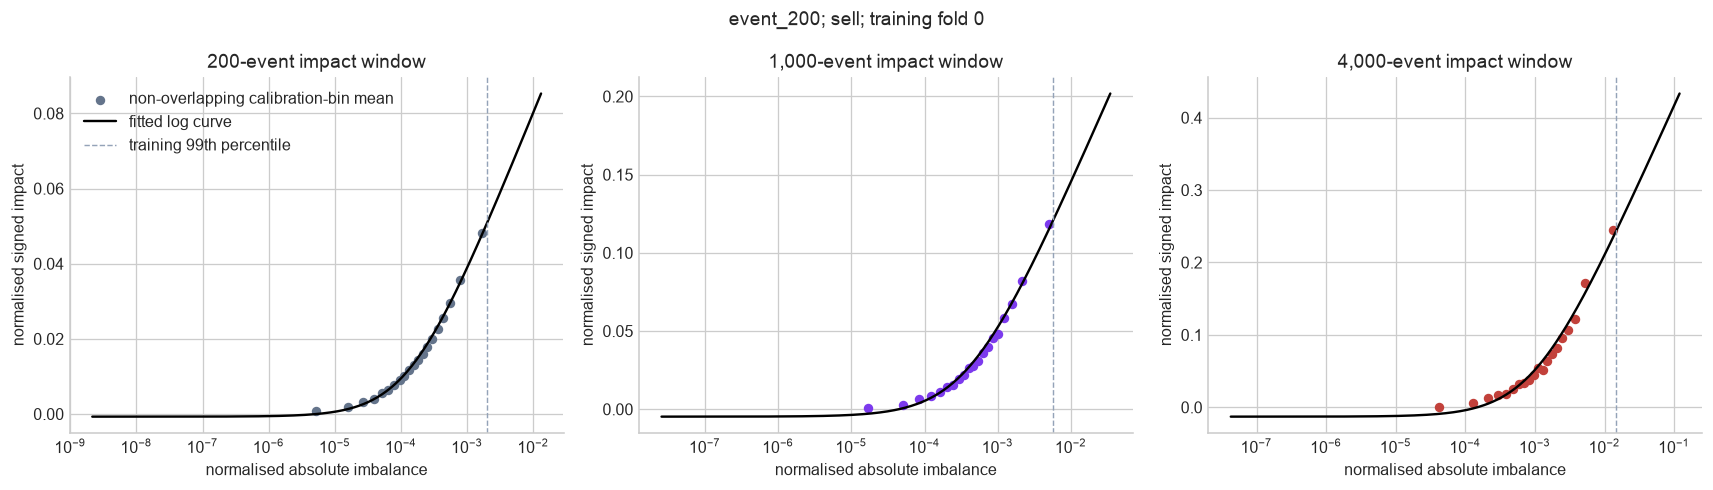

measurement_events,observations,rolling_training_observations,calibration_stride_decision_bars,imbalance_scale,intercept,slope,r_squared,training_x_p01,training_x_p99,training_x_max,training_median_duration_minutes
i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
200,235285,235285,1,0.00014,-0.000701,0.018889,0.232101,0.000002,0.002018,0.013119,0.644617
1000,47325,236772,5,0.000415,-0.004722,0.046592,0.239532,0.000007,0.005746,0.034559,3.472817
4000,11945,238713,20,0.000997,-0.012907,0.093051,0.242649,0.000017,0.014746,0.119689,14.817817


In [4]:
fig, axes = plt.subplots(1, len(available_windows),
                         figsize=(5 * len(available_windows), 4.3), squeeze=False)
for ax, window in zip(axes.flat, available_windows):
    chosen = curve_bins.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('measurement_events') == window) &
        (pl.col('fold') == FOLD) &
        (pl.col('side') == SIDE)
    ).sort('mean_normalised_imbalance')
    ax.scatter(chosen['mean_normalised_imbalance'],
               chosen['mean_normalised_signed_impact'], s=24,
               color=COLOURS.get(window, '#334155'),
               label='non-overlapping calibration-bin mean')
    fit_row = fits.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('measurement_events') == window) &
        (pl.col('fold') == FOLD) &
        (pl.col('side') == SIDE)
    ).row(0, named=True)
    x_grid = np.geomspace(fit_row['training_x_min'], fit_row['training_x_max'], 400)
    fitted_grid = (
        fit_row['intercept'] + fit_row['slope'] *
        np.log1p(x_grid / fit_row['imbalance_scale'])
    )
    ax.plot(x_grid, fitted_grid, color='black', lw=1.5,
            label='fitted log curve')
    ax.axvline(fit_row['training_x_p99'], color='#94a3b8', ls='--', lw=.9,
               label='training 99th percentile')
    ax.set_xscale('log')
    ax.set_title(f'{window:,}-event impact window')
    ax.set_xlabel('normalised absolute imbalance')
    ax.set_ylabel('normalised signed impact')
axes.flat[0].legend()
fig.suptitle(f'event_{DECISION_EVENTS}; {SIDE}; training fold {FOLD}')
plt.tight_layout()
plt.show()

display(fits.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).select('measurement_events', 'observations', 'rolling_training_observations',
         'calibration_stride_decision_bars', 'imbalance_scale',
         'intercept', 'slope', 'r_squared', 'training_x_p01', 'training_x_p99',
         'training_x_max', 'training_median_duration_minutes'))

## Compare impact-curve families

The original residual uses an affine logarithmic curve fitted to every
non-overlapping calibration block:

$$
I(x)=a+b\log\left(1+\frac{x}{c}\right).
$$

Three training-only diagnostics fitted to the same non-overlapping blocks are
shown beside it:

- `binned_log_zero`: a logarithmic curve constrained through zero and fitted to
  20 equal-count training-bin means, matching the broad academic fitting approach;
- `binned_power`: a power law fitted to the same training-bin means;
- `monotonic_bins`: a monotone interpolation through training-bin means, used as
  a flexible diagnostic benchmark rather than a proposed trading model.

The test panel uses the following chronological fold without refitting any model.
Its imbalance bins are also frozen from the training period.

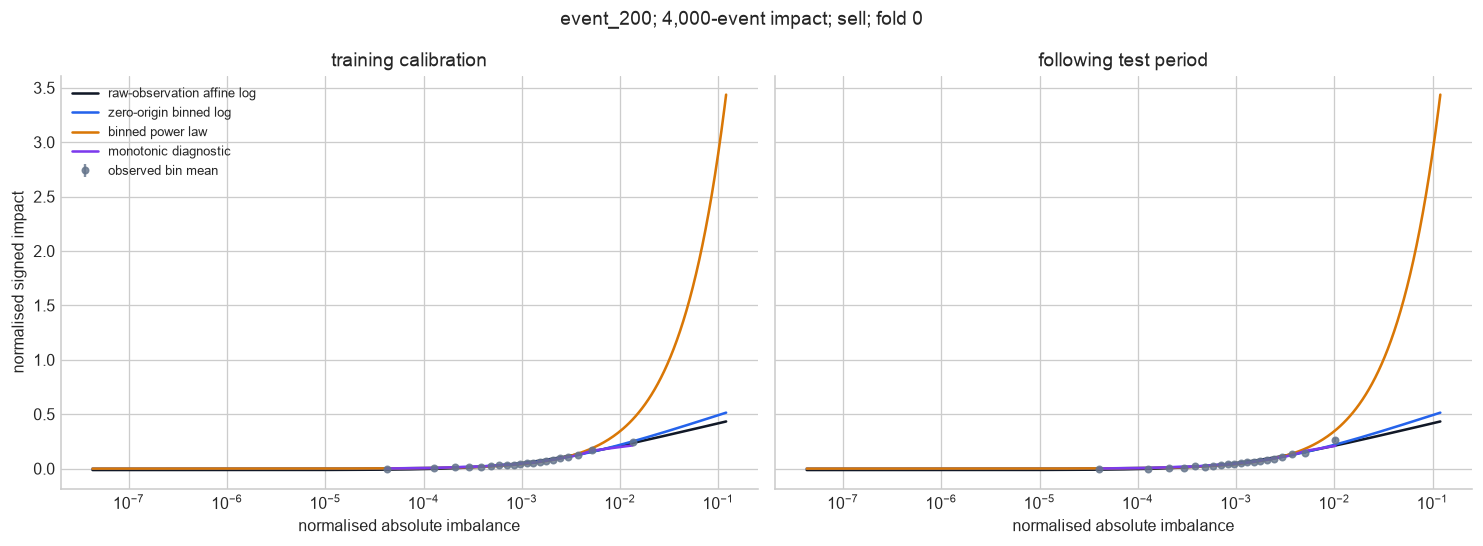

construction,decision_events,measurement_events,fold,side,calibration_stride_decision_bars,calibration_sampling,training_x_min,training_x_p01,training_x_p05,training_x_p50,training_x_p95,training_x_p99,training_x_p999,training_x_max,period,model,bins,bin_rmse,weighted_bin_rmse,bin_mae,maximum_absolute_bin_residual,mean_bin_bias
str,i64,i64,i64,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,f64,f64,f64,f64,f64
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""test""","""binned_log_zero""",20,0.012909,0.009265,0.007296,0.050547,-0.001676
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""test""","""monotonic_bins""",20,0.014758,0.010532,0.008183,0.056338,-0.001041
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""test""","""raw_log_affine""",20,0.014985,0.010728,0.009387,0.05855,-0.00255
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""test""","""binned_power""",20,0.021702,0.014716,0.011069,0.084411,-0.007269
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""train""","""binned_log_zero""",20,0.005906,0.005906,0.003637,0.01849,0.000695
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""train""","""monotonic_bins""",20,0.007297,0.007301,0.002653,0.031476,0.001861
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""train""","""raw_log_affine""",20,0.009759,0.009761,0.007994,0.026404,-0.000002
"""event_200""",200,4000,0,"""sell""",20,"""non_overlapping_measurement_bl…",4.2631e-8,0.000017,0.000085,0.001039,0.006489,0.014746,0.061258,0.119689,"""train""","""binned_power""",20,0.044775,0.044803,0.014697,0.19819,-0.00893


In [5]:
MODEL_LABELS = {
    'raw_log_affine': 'raw-observation affine log',
    'binned_log_zero': 'zero-origin binned log',
    'binned_power': 'binned power law',
    'monotonic_bins': 'monotonic diagnostic',
}
MODEL_COLOURS = {
    'raw_log_affine': '#111827',
    'binned_log_zero': '#2563eb',
    'binned_power': '#d97706',
    'monotonic_bins': '#7c3aed',
}
selected_diagnostics = diagnostic_bins.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).sort('impact_bin')

selected_parameters = diagnostic_parameters.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
)

def parameter_curve(row, x):
    if row['model'] == 'raw_log_affine':
        return row['intercept'] + row['slope'] * np.log1p(x / row['scale'])
    if row['model'] == 'binned_log_zero':
        return row['amplitude'] * np.log1p(row['curvature'] * x / row['scale'])
    if row['model'] == 'binned_power':
        return row['amplitude'] * x ** row['exponent']
    raise KeyError(row['model'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, period in zip(axes, ['train', 'test']):
    period_data = selected_diagnostics.filter(pl.col('period') == period)
    observed = period_data.filter(pl.col('model') == 'raw_log_affine')
    ax.errorbar(observed['mean_normalised_imbalance'],
                observed['mean_normalised_signed_impact'],
                yerr=observed['standard_error'], fmt='o', ms=4,
                color='#64748b', alpha=.8, label='observed bin mean')
    period_tail = diagnostic_tail_bins.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
        (pl.col('fold') == FOLD) &
        (pl.col('side') == SIDE) &
        (pl.col('period') == period)
    )
    support_max = max(selected_parameters['training_x_max'][0],
                      period_tail['maximum_normalised_imbalance'].max())
    x_grid = np.geomspace(selected_parameters['training_x_min'][0], support_max, 400)
    for model in ['raw_log_affine', 'binned_log_zero', 'binned_power']:
        row = selected_parameters.filter(pl.col('model') == model).row(0, named=True)
        ax.plot(x_grid, parameter_curve(row, x_grid),
                color=MODEL_COLOURS[model], lw=1.6, label=MODEL_LABELS[model])
    chosen = period_data.filter(pl.col('model') == 'monotonic_bins')
    ax.plot(chosen['mean_normalised_imbalance'], chosen['mean_predicted_impact'],
            color=MODEL_COLOURS['monotonic_bins'], lw=1.6,
            label=MODEL_LABELS['monotonic_bins'])
    ax.set_xscale('log')
    ax.set_xlabel('normalised absolute imbalance')
    ax.set_title('training calibration' if period == 'train' else 'following test period')
axes[0].set_ylabel('normalised signed impact')
axes[0].legend(fontsize=8)
fig.suptitle(f'event_{DECISION_EVENTS}; {FIT_MEASUREMENT_EVENTS:,}-event impact; '
             f'{SIDE}; fold {FOLD}')
plt.tight_layout()
plt.show()

selected_metrics = diagnostic_metrics.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).sort('period', 'bin_rmse')
display(selected_metrics)

## What happens at very low and very high imbalance?

The following bands use cut points frozen from the non-overlapping training blocks.
The tails are deliberately resolved more finely than the central 20%–80% region.
`aligned return` is the raw price return multiplied by the sign of the measurement
window's net imbalance. A positive value is movement in the direction of the flow;
a negative value is an immediate reversal.

Near-zero net imbalance does not necessarily imply zero conditional return: a bar
can contain large offsetting buy and sell flow, and conditioning on the eventual net
side can retain selection effects. The first bands let us see rather than assume
what the intercept should be.

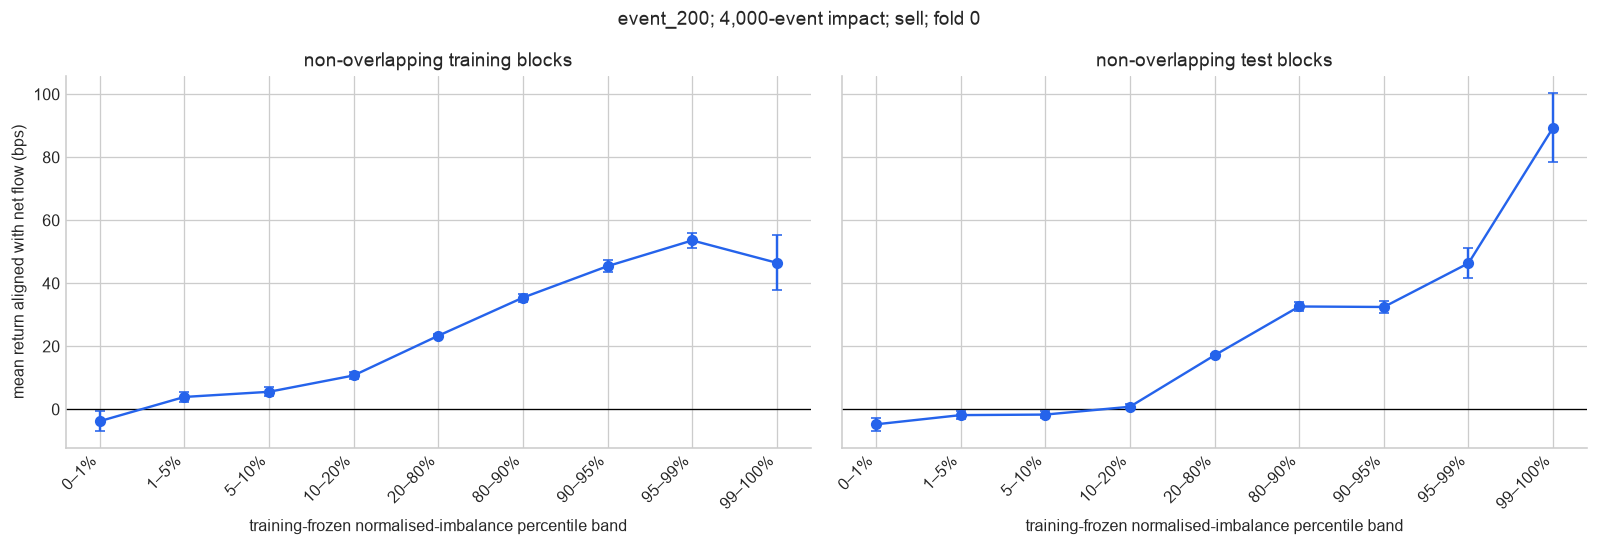

period,quantile_low,quantile_high,observations,minimum_normalised_imbalance,mean_normalised_imbalance,maximum_normalised_imbalance,mean_aligned_return_bps,median_aligned_return_bps,mean_normalised_signed_impact
str,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""test""",0.0,0.01,61,5.1292e-7,0.000009,0.000017,-4.764871,-5.398988,-0.013507
"""test""",0.01,0.05,220,0.000018,0.000049,0.000084,-1.836887,-1.538319,-0.000558
"""test""",0.05,0.1,286,0.000085,0.000128,0.00017,-1.669909,-2.721031,-0.003537
"""test""",0.1,0.2,512,0.000172,0.000253,0.000338,0.815853,0.866474,0.002022
"""test""",0.2,0.8,3434,0.000338,0.001141,0.002658,17.145864,15.654217,0.04831
…,…,…,…,…,…,…,…,…,…
"""train""",0.2,0.8,7167,0.000338,0.001178,0.00266,23.355234,17.434626,0.051172
"""train""",0.8,0.9,1194,0.002661,0.003351,0.004276,35.449937,28.975204,0.114948
"""train""",0.9,0.95,597,0.004278,0.005169,0.006485,45.440647,37.87502,0.172152


In [6]:
selected_tail = diagnostic_tail_bins.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).sort('period', 'quantile_low')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, period in zip(axes, ['train', 'test']):
    chosen = selected_tail.filter(pl.col('period') == period)
    labels = [f"{100*a:g}–{100*b:g}%" for a, b in
              zip(chosen['quantile_low'], chosen['quantile_high'])]
    positions = np.arange(chosen.height)
    ax.errorbar(positions, chosen['mean_aligned_return_bps'],
                yerr=chosen['return_standard_error_bps'], fmt='o-', capsize=3,
                color='#2563eb')
    ax.axhline(0, color='black', lw=.8)
    ax.set_xticks(positions, labels, rotation=45, ha='right')
    ax.set_xlabel('training-frozen normalised-imbalance percentile band')
    ax.set_title('non-overlapping training blocks' if period == 'train'
                 else 'non-overlapping test blocks')
axes[0].set_ylabel('mean return aligned with net flow (bps)')
fig.suptitle(f'event_{DECISION_EVENTS}; {FIT_MEASUREMENT_EVENTS:,}-event impact; '
             f'{SIDE}; fold {FOLD}')
plt.tight_layout()
plt.show()

display(selected_tail.select(
    'period', 'quantile_low', 'quantile_high', 'observations',
    'minimum_normalised_imbalance', 'mean_normalised_imbalance',
    'maximum_normalised_imbalance', 'mean_aligned_return_bps',
    'median_aligned_return_bps', 'mean_normalised_signed_impact'
))

## Is the upper imbalance tail controlling the log fit?

These are sensitivity fits, not alternative factors selected after viewing the
test result. They hold the full-sample imbalance scale fixed and refit only the
intercept and slope after excluding the highest 1% or 5% of training imbalance.
This isolates upper-tail leverage from a change in the horizontal normalisation.

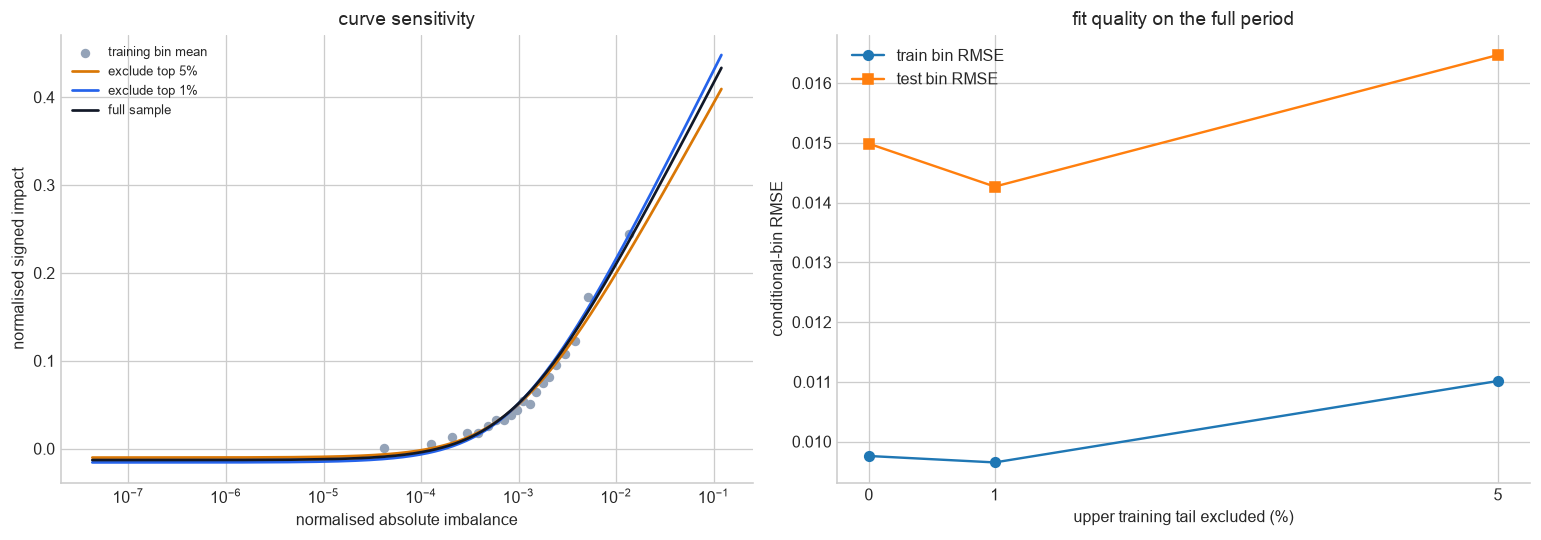

period,upper_training_quantile,upper_x_cut,fit_observations,intercept,slope,bin_rmse,maximum_absolute_bin_residual,mean_bin_bias
str,f64,f64,i64,f64,f64,f64,f64,f64
"""train""",0.95,0.006489,11347,-0.01011,0.08746,0.011015,0.037509,0.001876
"""test""",0.95,0.006489,11347,-0.01011,0.08746,0.016471,0.068968,-0.000718
"""train""",0.99,0.014746,11825,-0.015634,0.096681,0.009651,0.020108,-0.000309
"""test""",0.99,0.014746,11825,-0.015634,0.096681,0.014268,0.052698,-0.002828
"""train""",1.0,0.119689,11945,-0.012907,0.093051,0.009759,0.026404,-0.000002
"""test""",1.0,0.119689,11945,-0.012907,0.093051,0.014985,0.05855,-0.00255


In [7]:
selected_trim = diagnostic_trim_sensitivity.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('measurement_events') == FIT_MEASUREMENT_EVENTS) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).sort('upper_training_quantile')

training_observed = selected_diagnostics.filter(
    (pl.col('period') == 'train') &
    (pl.col('model') == 'raw_log_affine')
)
full_support = selected_parameters.filter(
    pl.col('model') == 'raw_log_affine'
).row(0, named=True)
x_grid = np.geomspace(full_support['training_x_min'],
                      full_support['training_x_max'], 400)
trim_colours = {0.95: '#d97706', 0.99: '#2563eb', 1.0: '#111827'}
trim_labels = {0.95: 'exclude top 5%', 0.99: 'exclude top 1%', 1.0: 'full sample'}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].scatter(training_observed['mean_normalised_imbalance'],
                training_observed['mean_normalised_signed_impact'],
                color='#94a3b8', s=24, label='training bin mean')
for quantile in [0.95, 0.99, 1.0]:
    row = selected_trim.filter(
        (pl.col('period') == 'train') &
        (pl.col('upper_training_quantile') == quantile)
    ).row(0, named=True)
    curve = row['intercept'] + row['slope'] * np.log1p(x_grid / row['scale'])
    axes[0].plot(x_grid, curve, color=trim_colours[quantile], lw=1.7,
                 label=trim_labels[quantile])
axes[0].set_xscale('log')
axes[0].set_xlabel('normalised absolute imbalance')
axes[0].set_ylabel('normalised signed impact')
axes[0].set_title('curve sensitivity')
axes[0].legend(fontsize=8)

for period, marker in [('train', 'o'), ('test', 's')]:
    chosen = selected_trim.filter(pl.col('period') == period).sort(
        'upper_training_quantile'
    )
    excluded = 100 * (1 - chosen['upper_training_quantile'].to_numpy())
    axes[1].plot(excluded, chosen['bin_rmse'], marker=marker,
                 label=f'{period} bin RMSE')
axes[1].set_xticks([0, 1, 5])
axes[1].set_xlabel('upper training tail excluded (%)')
axes[1].set_ylabel('conditional-bin RMSE')
axes[1].set_title('fit quality on the full period')
axes[1].legend()
plt.tight_layout()
plt.show()

display(selected_trim.select(
    'period', 'upper_training_quantile', 'upper_x_cut', 'fit_observations',
    'intercept', 'slope', 'bin_rmse', 'maximum_absolute_bin_residual',
    'mean_bin_bias'
))

### Comparison with the recent academic graphs

The 2025–2026 academic graphs are not yet a controlled time comparison. They use
legacy reconstructed events, continuous non-overlapping 4,000-event blocks and a
log curve fitted to binned conditional means. This sandbox now also calibrates on
continuous non-overlapping blocks, but uses corrected events and, for the original
residual, an affine log curve fitted to individual block observations. The frozen
curve is subsequently applied to rolling measurements on the shorter decision clock.

The recent academic sample's median 4,000-event duration was about 5.2 minutes.
Within the older corrected-data folds shown here, the training median changes from
roughly 14 minutes in the earliest fold to roughly 3.4 minutes in the latest fold.
That establishes substantial activity evolution, but not by itself a change in the
structural impact function. A controlled comparison requires the corrected parser
and identical fitting procedure over the extended history.

## Conditional calibration error

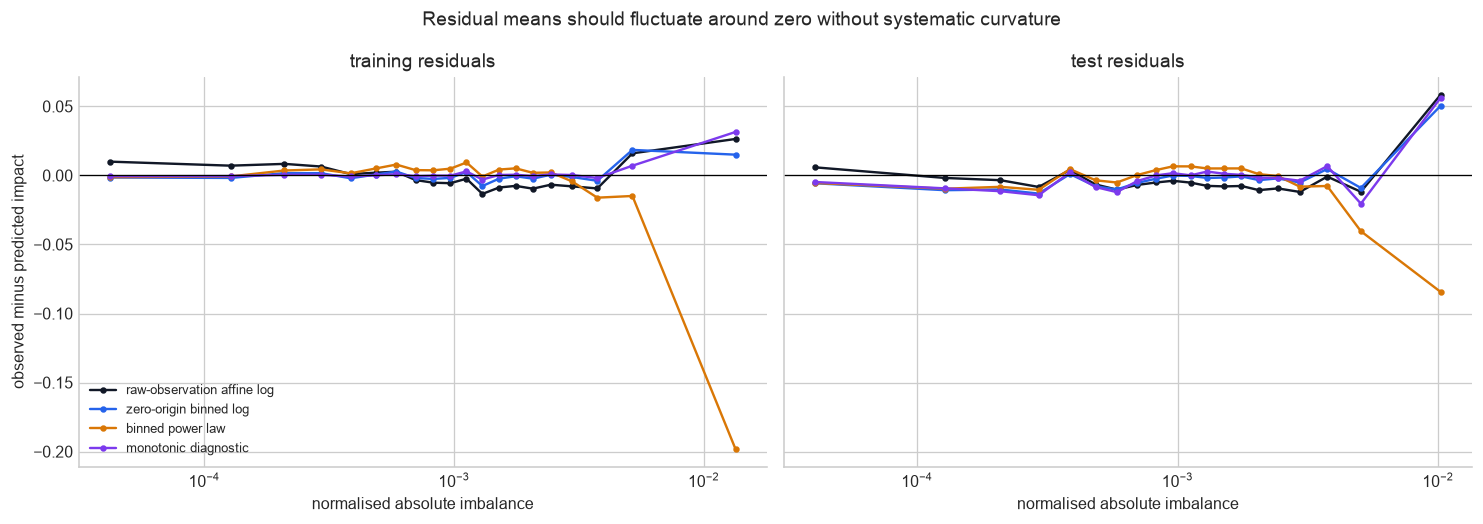

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, period in zip(axes, ['train', 'test']):
    period_data = selected_diagnostics.filter(pl.col('period') == period)
    for model in MODEL_LABELS:
        chosen = period_data.filter(pl.col('model') == model)
        ax.plot(chosen['mean_normalised_imbalance'], chosen['mean_residual'],
                marker='o', ms=3, color=MODEL_COLOURS[model],
                label=MODEL_LABELS[model])
    ax.axhline(0, color='black', lw=.8)
    ax.set_xscale('log')
    ax.set_xlabel('normalised absolute imbalance')
    ax.set_title('training residuals' if period == 'train' else 'test residuals')
axes[0].set_ylabel('observed minus predicted impact')
axes[0].legend(fontsize=8)
fig.suptitle('Residual means should fluctuate around zero without systematic curvature')
plt.tight_layout()
plt.show()

## Calibration drift across folds

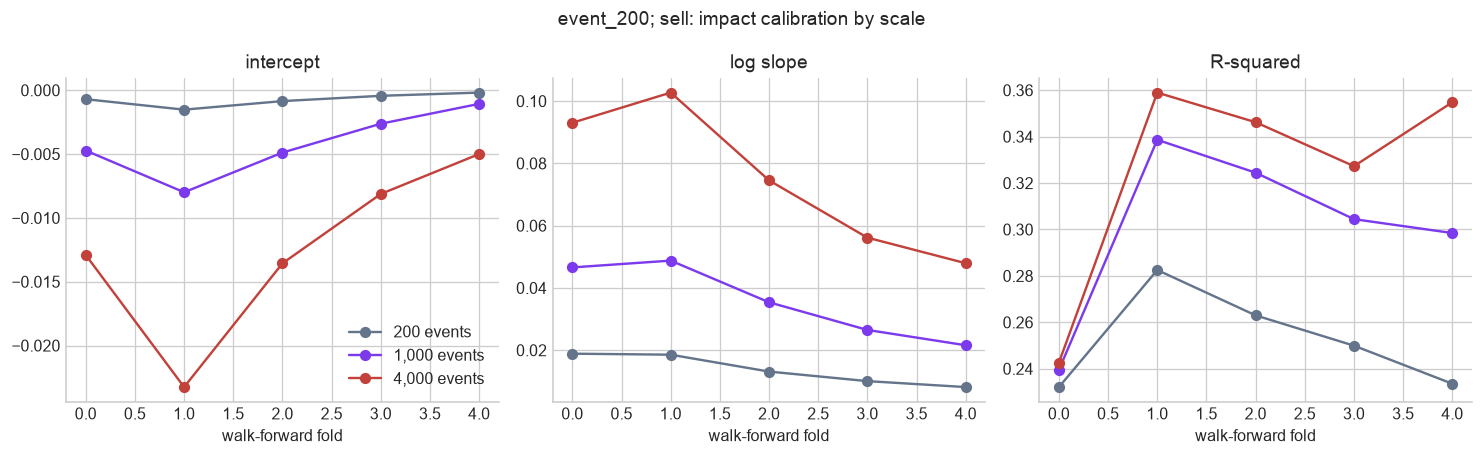

In [9]:
part = fits.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('side') == SIDE)
).sort('fold')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for window in available_windows:
    chosen = part.filter(pl.col('measurement_events') == window)
    colour = COLOURS.get(window, '#334155')
    axes[0].plot(chosen['fold'], chosen['intercept'], marker='o', color=colour,
                 label=f'{window:,} events')
    axes[1].plot(chosen['fold'], chosen['slope'], marker='o', color=colour)
    axes[2].plot(chosen['fold'], chosen['r_squared'], marker='o', color=colour)
for ax, title in zip(axes, ['intercept', 'log slope', 'R-squared']):
    ax.set_title(title)
    ax.set_xlabel('walk-forward fold')
axes[0].legend()
fig.suptitle(f'event_{DECISION_EVENTS}; {SIDE}: impact calibration by scale')
plt.tight_layout()
plt.show()

## Residual threshold drift

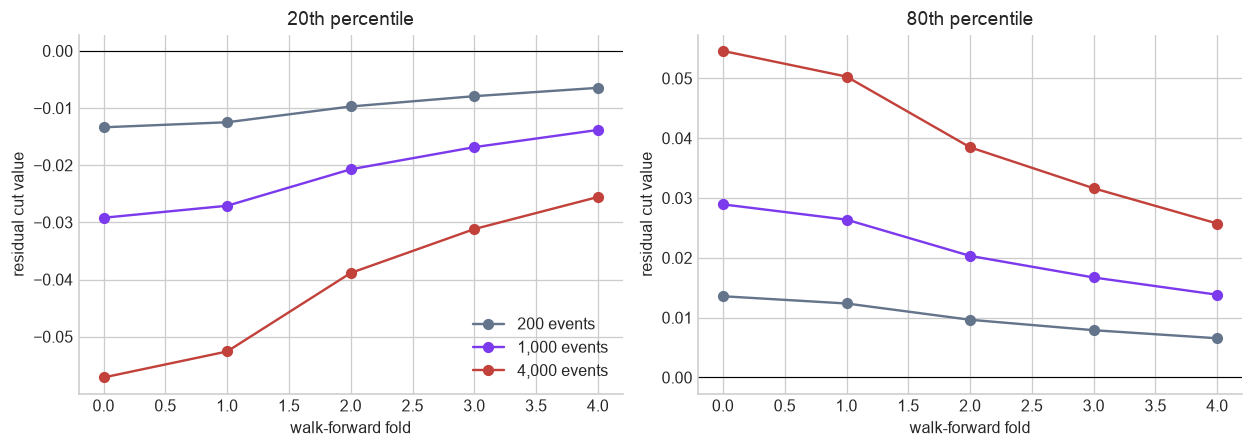

In [10]:
part = cuts.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('side') == SIDE) &
    (pl.col('cut_number').is_in([1, 4]))
).sort('fold')
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, cut_number, title in zip(axes, [1, 4], ['20th percentile', '80th percentile']):
    for window in available_windows:
        chosen = part.filter(
            (pl.col('measurement_events') == window) &
            (pl.col('cut_number') == cut_number)
        )
        ax.plot(chosen['fold'], chosen['cut_value'], marker='o',
                color=COLOURS.get(window, '#334155'), label=f'{window:,} events')
    ax.axhline(0, color='black', lw=.7)
    ax.set_title(title)
    ax.set_xlabel('walk-forward fold')
    ax.set_ylabel('residual cut value')
axes[0].legend()
plt.tight_layout()
plt.show()

## Out-of-sample response across residual quintiles

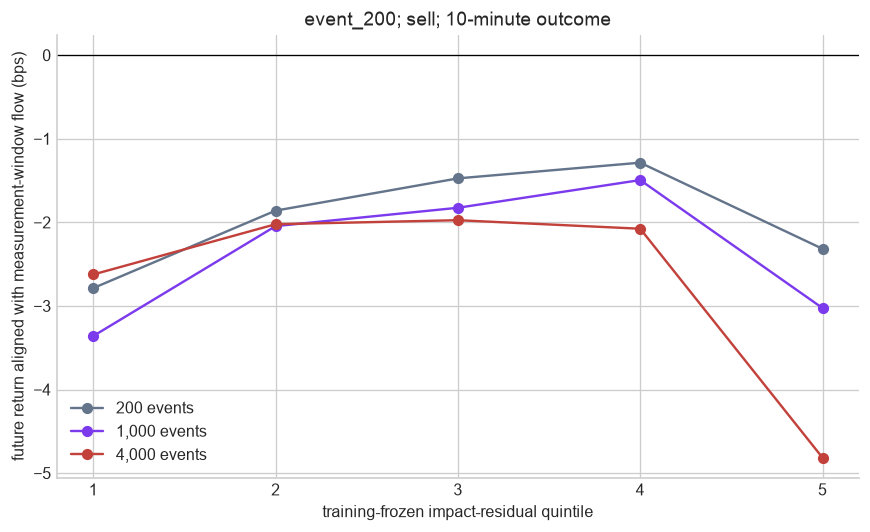

measurement_events,residual_quantile,mean_across_folds_bps,median_across_folds_bps
i64,i64,f64,f64
200,1,-2.786526,-2.390063
200,2,-1.85987,-1.31474
200,3,-1.473982,-1.183089
200,4,-1.286298,-1.287783
200,5,-2.316454,-1.947102
…,…,…,…
4000,1,-2.623686,-1.8443
4000,2,-2.022374,-1.617901
4000,3,-1.974434,-1.590684


In [11]:
profile = (
    quintiles.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('horizon_minutes') == HORIZON_MINUTES) &
        (pl.col('side') == SIDE)
    )
    .group_by('measurement_events', 'residual_quantile')
    .agg(
        pl.col('day_mean_aligned_return_bps').mean().alias('mean_across_folds_bps'),
        pl.col('day_mean_aligned_return_bps').median().alias('median_across_folds_bps'),
    )
    .sort('measurement_events', 'residual_quantile')
)
fig, ax = plt.subplots(figsize=(9, 5))
for window in available_windows:
    chosen = profile.filter(pl.col('measurement_events') == window)
    ax.plot(chosen['residual_quantile'], chosen['mean_across_folds_bps'], marker='o',
            color=COLOURS.get(window, '#334155'), label=f'{window:,} events')
ax.axhline(0, color='black', lw=.8)
ax.set_xticks(range(1, 6))
ax.set_xlabel('training-frozen impact-residual quintile')
ax.set_ylabel('future return aligned with measurement-window flow (bps)')
ax.set_title(f'event_{DECISION_EVENTS}; {SIDE}; {HORIZON_MINUTES}-minute outcome')
ax.legend()
plt.show()
display(profile)

## High-minus-low residual spread by chronological fold

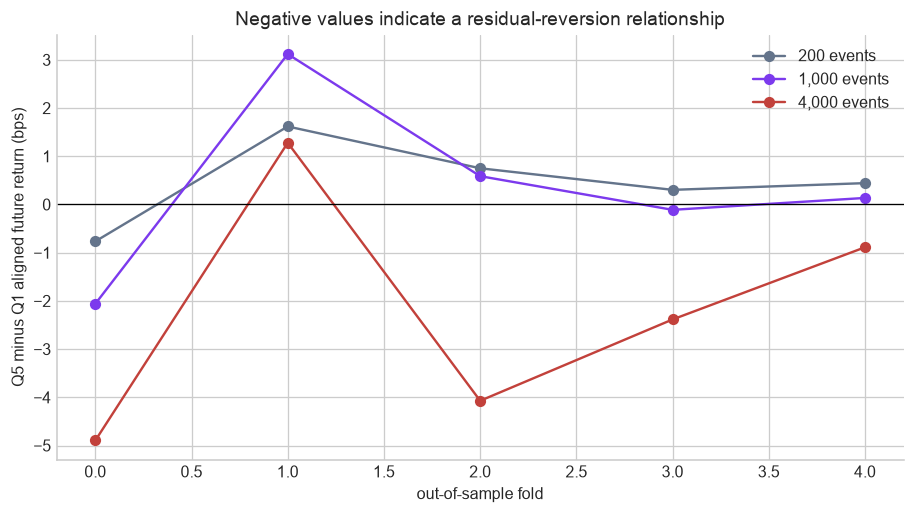

measurement_events,fold,test_start,test_end,paired_days,day_mean_difference_bps,day_t_stat
i64,i64,str,str,i64,f64,f64
200,0,"""2020-09-01""","""2020-12-01""",91,-0.765119,-1.469247
1000,0,"""2020-09-01""","""2020-12-01""",91,-2.060338,-2.209673
4000,0,"""2020-09-01""","""2020-12-01""",91,-4.895346,-2.669381
200,1,"""2020-12-01""","""2021-03-01""",90,1.618274,2.150071
1000,1,"""2020-12-01""","""2021-03-01""",90,3.119849,2.609656
…,…,…,…,…,…,…
1000,3,"""2021-06-01""","""2021-09-01""",92,-0.110968,-0.282389
4000,3,"""2021-06-01""","""2021-09-01""",92,-2.384595,-1.639161
200,4,"""2021-09-01""","""2021-12-01""",91,0.442961,1.24078


In [12]:
part = contrasts.filter(
    (pl.col('decision_events') == DECISION_EVENTS) &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE)
).sort('fold')
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for window in available_windows:
    chosen = part.filter(pl.col('measurement_events') == window)
    ax.plot(chosen['fold'], chosen['day_mean_difference_bps'], marker='o',
            color=COLOURS.get(window, '#334155'), label=f'{window:,} events')
ax.axhline(0, color='black', lw=.8)
ax.set_xlabel('out-of-sample fold')
ax.set_ylabel('Q5 minus Q1 aligned future return (bps)')
ax.set_title('Negative values indicate a residual-reversion relationship')
ax.legend()
plt.show()
display(part.select('measurement_events', 'fold', 'test_start', 'test_end',
                    'paired_days', 'day_mean_difference_bps', 'day_t_stat'))

## Summary across folds and scales

In [13]:
summary = aggregate.filter(
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE)
).sort('reversion_fold_share', 'median_spread_bps', descending=[True, False])
display(summary)

construction,decision_events,measurement_events,horizon_minutes,side,comparison,folds,mean_spread_bps,median_spread_bps,minimum_spread_bps,reversion_fold_share
str,i64,i64,i64,str,str,i64,f64,f64,f64,f64
"""event_200""",200,4000,10,"""sell""","""q5_minus_q1_aligned_return""",5,-2.19186,-2.384595,-4.895346,0.8
"""event_500""",500,4000,10,"""sell""","""q5_minus_q1_aligned_return""",5,-1.455542,-1.383289,-4.13568,0.8
"""event_1000""",1000,4000,10,"""sell""","""q5_minus_q1_aligned_return""",5,-1.185874,-0.613034,-3.83827,0.8
"""event_1000""",1000,1000,10,"""sell""","""q5_minus_q1_aligned_return""",5,0.602363,-0.243926,-0.957696,0.6
"""event_500""",500,1000,10,"""sell""","""q5_minus_q1_aligned_return""",5,0.143677,-0.122708,-2.098944,0.6
"""event_200""",200,1000,10,"""sell""","""q5_minus_q1_aligned_return""",5,0.334285,0.135599,-2.060338,0.4
"""event_500""",500,500,10,"""sell""","""q5_minus_q1_aligned_return""",5,0.22193,0.446203,-0.545022,0.4
"""event_200""",200,200,10,"""sell""","""q5_minus_q1_aligned_return""",5,0.470072,0.442961,-0.765119,0.2


## Are the residual scales distinct?

first_measurement_events,second_measurement_events,mean_fold_correlation,minimum_fold_correlation,maximum_fold_correlation
i64,i64,f64,f64,f64
200,1000,0.408017,0.391025,0.418481
200,4000,0.181275,0.15317,0.214131
1000,4000,0.462212,0.439048,0.488069


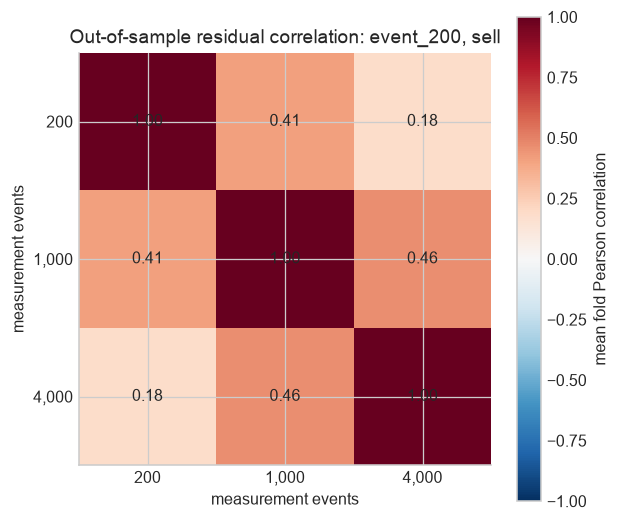

In [14]:
corr = (
    correlations.filter(
        (pl.col('decision_events') == DECISION_EVENTS) &
        (pl.col('side') == SIDE)
    )
    .group_by('first_measurement_events', 'second_measurement_events')
    .agg(
        pl.col('pearson_correlation').mean().alias('mean_fold_correlation'),
        pl.col('pearson_correlation').min().alias('minimum_fold_correlation'),
        pl.col('pearson_correlation').max().alias('maximum_fold_correlation'),
    )
    .sort('first_measurement_events', 'second_measurement_events')
)
display(corr)

matrix = np.eye(len(available_windows))
for row in corr.iter_rows(named=True):
    i = available_windows.index(row['first_measurement_events'])
    j = available_windows.index(row['second_measurement_events'])
    matrix[i, j] = matrix[j, i] = row['mean_fold_correlation']
fig, ax = plt.subplots(figsize=(5.5, 4.8))
image = ax.imshow(matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(available_windows)), [f'{x:,}' for x in available_windows])
ax.set_yticks(range(len(available_windows)), [f'{x:,}' for x in available_windows])
ax.set_xlabel('measurement events')
ax.set_ylabel('measurement events')
ax.set_title(f'Out-of-sample residual correlation: event_{DECISION_EVENTS}, {SIDE}')
for i in range(len(available_windows)):
    for j in range(len(available_windows)):
        ax.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax, label='mean fold Pearson correlation')
plt.tight_layout()
plt.show()

## Interpretation discipline

- A negative Q5-minus-Q1 spread is evidence of relative reversion, not yet a net trading return.
- Examine buy and sell sides separately; the earlier residual evidence was asymmetric.
- Impact-curve calibration blocks do not overlap. The rolling factor values and forward-return labels used in the signal screen can overlap, so treat adjacent signals as dependent.
- Compare scale consistency across chronological folds, not merely the pooled mean.
- The existing cache predates fingerprint manifests; this sandbox run is deliberately marked unverified. Rebuild the caches after extending the dataset.
- Entry delay, simultaneous positions, fees, spread and slippage belong in the later strategy simulation.